# Network Intrusion Detection using Machine Learning

## Data Mining Final Project

In this project, we design a machine learning-based decision support system for detecting suspicious network connections.

The dataset used in this project is the KDD Cup 1999 Intrusion Detection dataset.

The main goal is to classify each network connection as:

- Normal
- Attack

This project follows a complete data mining pipeline:
1. Data understanding
2. Data quality checking
3. Data cleaning
4. Exploratory data analysis
5. Preprocessing
6. Classification modeling
7. Model evaluation
8. Dimensionality reduction
9. Clustering analysis

In [1]:
import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    RocCurveDisplay
)

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
# Detect project root
PROJECT_ROOT = Path.cwd()

# If notebook is running from the notebooks folder, go one level up
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
ZIP_PATH = DATA_DIR / "4.zip"
EXTRACTED_DIR = DATA_DIR / "extracted"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

EXTRACTED_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset ZIP path:", ZIP_PATH)
print("Extracted data path:", EXTRACTED_DIR)

Project root: /Users/arshia_mmz/Desktop/Uni/term 6/داده کاوی/Data-Mining/network-intrusion-detection-ml
Dataset ZIP path: /Users/arshia_mmz/Desktop/Uni/term 6/داده کاوی/Data-Mining/network-intrusion-detection-ml/data/4.zip
Extracted data path: /Users/arshia_mmz/Desktop/Uni/term 6/داده کاوی/Data-Mining/network-intrusion-detection-ml/data/extracted


In [3]:
if ZIP_PATH.exists():
    print("Dataset ZIP file found.")
else:
    raise FileNotFoundError("4.zip was not found. Please place it inside the data folder.")

Dataset ZIP file found.


In [4]:
with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_files = zip_ref.namelist()

zip_contents = pd.DataFrame({
    "file_name": zip_files
})

zip_contents

,file_name
0,corrected.gz
1,corrected/corrected
2,kddcup.data.corrected
3,kddcup.data.gz
4,kddcup.data/kddcup.data
5,kddcup.data_10_percent.gz
6,kddcup.data_10_percent/kddcup.data_10_percent
7,kddcup.data_10_percent_corrected
8,kddcup.names
9,kddcup.newtestdata_10_percent_unlabeled.gz


In [5]:
with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACTED_DIR)

print("ZIP file extracted successfully.")

ZIP file extracted successfully.


In [6]:
extracted_files = list(EXTRACTED_DIR.rglob("*"))

for file in extracted_files:
    if file.is_file():
        print(file.relative_to(EXTRACTED_DIR))

kddcup.newtestdata_10_percent_unlabeled.gz
kddcup.data_10_percent.gz
kddcup.names
corrected.gz
training_attack_types
kddcup.testdata.unlabeled_10_percent.gz
kddcup.data_10_percent_corrected
kddcup.testdata.unlabeled.gz
kddcup.data.gz
kddcup.data.corrected
typo-correction.txt
kddcup.testdata.unlabeled/kddcup.testdata.unlabeled
kddcup.data_10_percent/kddcup.data_10_percent
kddcup.testdata.unlabeled_10_percent/kddcup.testdata.unlabeled_10_percent
kddcup.newtestdata_10_percent_unlabeled/kddcup.newtestdata_10_percent_unlabeled
kddcup.data/kddcup.data
corrected/corrected


In [7]:
names_file = next(EXTRACTED_DIR.rglob("kddcup.names"))

with open(names_file, "r") as file:
    lines = file.readlines()

feature_names = []

for line in lines:
    line = line.strip()
    if ":" in line:
        feature_name = line.split(":")[0]
        feature_names.append(feature_name)

column_names = feature_names + ["label"]

print("Number of features:", len(feature_names))
print("Number of columns including label:", len(column_names))
print(column_names)

Number of features: 41
Number of columns including label: 42
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label']


In [8]:
data_file = next(EXTRACTED_DIR.rglob("kddcup.data_10_percent_corrected"))

df = pd.read_csv(data_file, names=column_names, low_memory=False)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (494021, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,SF,181,5450,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,9,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,239,486,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,19,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,235,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,29,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
3,0,tcp,http,SF,219,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,39,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
4,0,tcp,http,SF,217,2032,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,49,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.


In [9]:
print("Dataset shape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

Dataset shape:
(494021, 42)

First 5 rows:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,SF,181,5450,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,9,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,239,486,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,19,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,235,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,29,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
3,0,tcp,http,SF,219,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,39,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
4,0,tcp,http,SF,217,2032,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,49,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 494021 entries, 0 to 494020
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     494021 non-null  int64  
 1   protocol_type                494021 non-null  str    
 2   service                      494021 non-null  str    
 3   flag                         494021 non-null  str    
 4   src_bytes                    494021 non-null  int64  
 5   dst_bytes                    494021 non-null  int64  
 6   land                         494021 non-null  int64  
 7   wrong_fragment               494021 non-null  int64  
 8   urgent                       494021 non-null  int64  
 9   hot                          494021 non-null  int64  
 10  num_failed_logins            494021 non-null  int64  
 11  logged_in                    494021 non-null  int64  
 12  num_compromised              494021 non-null  i

In [10]:
df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,494021.000000,4.940210e+05,4.940210e+05,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.0,494021.0,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000,494021.000000
mean,47.979302,3.025610e+03,8.685324e+02,0.000045,0.006433,0.000014,0.034519,0.000152,0.148247,0.010212,0.000111,0.000036,0.011352,0.001083,0.000109,0.001008,0.0,0.0,0.001387,332.285690,292.906557,0.176687,0.176609,0.057433,0.057719,0.791547,0.020982,0.028997,232.470778,188.665670,0.753780,0.030906,0.601935,0.006684,0.176754,0.176443,0.058118,0.057412
std,707.746472,9.882181e+05,3.304000e+04,0.006673,0.134805,0.005510,0.782103,0.015520,0.355345,1.798326,0.010551,0.007793,2.012718,0.096416,0.011020,0.036482,0.0,0.0,0.037211,213.147412,246.322817,0.380717,0.381017,0.231623,0.232147,0.388189,0.082205,0.142397,64.745380,106.040437,0.410781,0.109259,0.481309,0.042133,0.380593,0.380919,0.230590,0.230140
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,4.500000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,117.000000,10.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,46.000000,0.410000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,5.200000e+02,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,510.000000,510.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,255.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,1.032000e+03,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,511.000000,511.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,255.000000,1.000000,0.040000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,58329.000000,6.933756e+08,5.155468e+06,1.000000,3.000000,3.000000,30.000000,5.000000,1.000000,884.000000,1.000000,2.000000,993.000000,28.000000,2.000000,8.000000,0.0,0.0,1.000000,511.000000,511.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
df.dtypes.value_counts()

int64      23
float64    15
str         4
Name: count, dtype: int64

In [12]:
categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns count:")
print(len(numerical_columns))

Categorical columns:
['protocol_type', 'service', 'flag', 'label']

Numerical columns count:
38


/var/folders/s3/bj6s78k94q94mmyl5jf6tq_40000gn/T/ipykernel_31819/2133677730.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()


In [13]:
df["label"].value_counts().head(20)

label
smurf.              280790
neptune.            107201
normal.              97278
back.                 2203
satan.                1589
ipsweep.              1247
portsweep.            1040
warezclient.          1020
teardrop.              979
pod.                   264
nmap.                  231
guess_passwd.           53
buffer_overflow.        30
land.                   21
warezmaster.            20
imap.                   12
rootkit.                10
loadmodule.              9
ftp_write.               8
multihop.                7
Name: count, dtype: int64

In [14]:
df["target"] = df["label"].apply(lambda x: 0 if x == "normal." else 1)

target_names = {
    0: "Normal",
    1: "Attack"
}

df["target_name"] = df["target"].map(target_names)

df[["label", "target", "target_name"]].head()

,label,target,target_name
0,normal.,0,Normal
1,normal.,0,Normal
2,normal.,0,Normal
3,normal.,0,Normal
4,normal.,0,Normal


In [15]:
df["target_name"].value_counts()

target_name
Attack    396743
Normal     97278
Name: count, dtype: int64

In [16]:
df["target_name"].value_counts(normalize=True) * 100

target_name
Attack    80.308934
Normal    19.691066
Name: proportion, dtype: float64

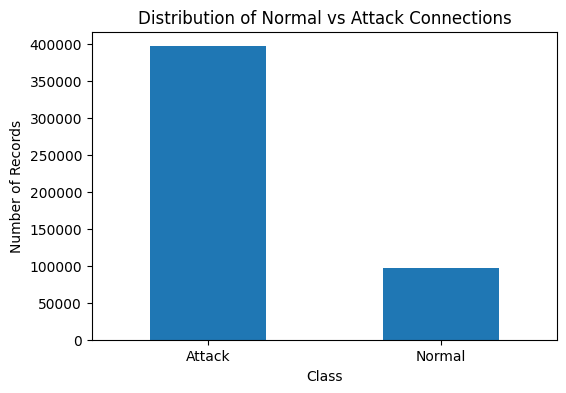

In [17]:
class_counts = df["target_name"].value_counts()

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Distribution of Normal vs Attack Connections")
plt.xlabel("Class")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

In [18]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [19]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)
print("Duplicate percentage:", round((duplicate_count / len(df)) * 100, 2), "%")

Number of duplicate rows: 348435
Duplicate percentage: 70.53 %


## Data Cleaning

In this section, we clean the dataset before modeling.

The main cleaning steps are:

1. Remove duplicate records
2. Check missing values again
3. Remove constant columns
4. Keep the original label column for analysis
5. Use the binary target column for modeling

Duplicate records are removed because repeated network connections may make the model overconfident and may lead to unrealistic evaluation results.

In [20]:
df_clean = df.copy()

print("Original dataset shape:", df_clean.shape)

Original dataset shape: (494021, 44)


In [21]:
duplicate_count_before = df_clean.duplicated().sum()

print("Duplicate rows before cleaning:", duplicate_count_before)
print("Duplicate percentage:", round((duplicate_count_before / len(df_clean)) * 100, 2), "%")

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df_clean.shape)

Duplicate rows before cleaning: 348435
Duplicate percentage: 70.53 %
Dataset shape after removing duplicates: (145586, 44)


In [22]:
missing_after_cleaning = df_clean.isnull().sum()
missing_after_cleaning[missing_after_cleaning > 0]

Series([], dtype: int64)

In [23]:
total_missing = df_clean.isnull().sum().sum()
print("Total missing values after cleaning:", total_missing)

Total missing values after cleaning: 0


In [24]:
constant_columns = []

for col in df_clean.columns:
    if df_clean[col].nunique(dropna=False) == 1:
        constant_columns.append(col)

print("Constant columns:")
print(constant_columns)

Constant columns:
['num_outbound_cmds', 'is_host_login']


In [25]:
columns_to_drop = [col for col in constant_columns if col not in ["label", "target", "target_name"]]

df_clean = df_clean.drop(columns=columns_to_drop)

print("Dropped columns:", columns_to_drop)
print("Dataset shape after dropping constant columns:", df_clean.shape)

Dropped columns: ['num_outbound_cmds', 'is_host_login']
Dataset shape after dropping constant columns: (145586, 42)


In [26]:
target_counts_clean = df_clean["target_name"].value_counts()
target_percent_clean = df_clean["target_name"].value_counts(normalize=True) * 100

target_distribution_clean = pd.DataFrame({
    "count": target_counts_clean,
    "percentage": target_percent_clean.round(2)
})

target_distribution_clean

,count,percentage
target_name,,
Normal,87832,60.33
Attack,57754,39.67


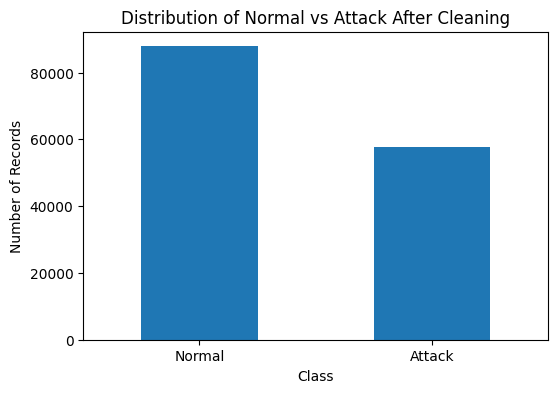

In [27]:
plt.figure(figsize=(6, 4))
target_counts_clean.plot(kind="bar")
plt.title("Distribution of Normal vs Attack After Cleaning")
plt.xlabel("Class")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

## Exploratory Data Analysis - EDA

In this section, we explore the cleaned dataset visually and statistically.

The goal of EDA is to better understand:

1. Class distribution
2. Attack type distribution
3. Protocol distribution
4. Service distribution
5. Relationships between numerical features
6. Differences between normal and attack connections

In [28]:
attack_type_counts = df_clean["label"].value_counts()

attack_type_counts.head(20)

label
normal.             87832
neptune.            51820
back.                 968
teardrop.             918
satan.                906
warezclient.          893
ipsweep.              651
smurf.                641
portsweep.            416
pod.                  206
nmap.                 158
guess_passwd.          53
buffer_overflow.       30
warezmaster.           20
land.                  19
imap.                  12
rootkit.               10
loadmodule.             9
ftp_write.              8
multihop.               7
Name: count, dtype: int64

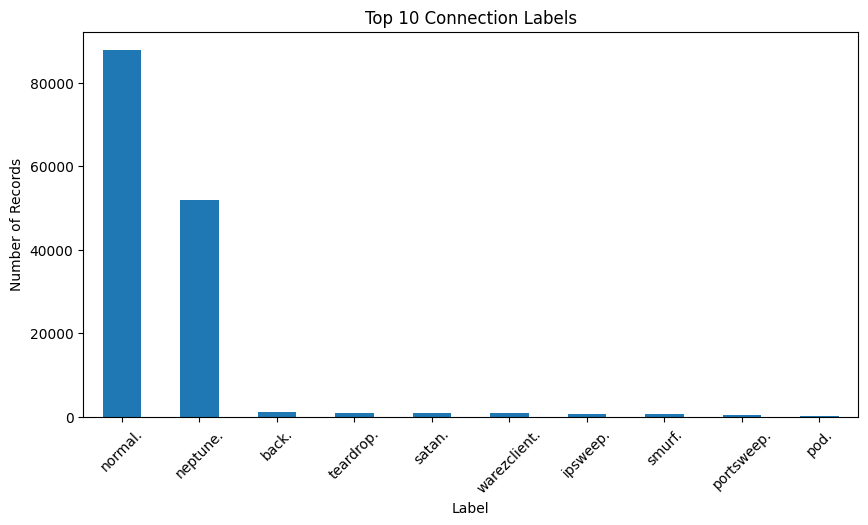

In [29]:
top_attack_types = df_clean["label"].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_attack_types.plot(kind="bar")
plt.title("Top 10 Connection Labels")
plt.xlabel("Label")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

In [30]:
protocol_counts = df_clean["protocol_type"].value_counts()

protocol_counts

protocol_type
tcp     130913
udp      12267
icmp      2406
Name: count, dtype: int64

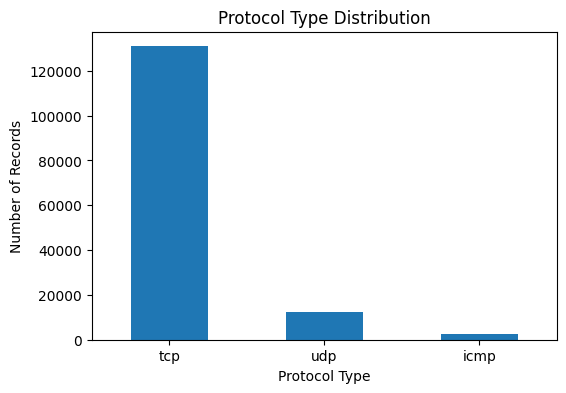

In [31]:
plt.figure(figsize=(6, 4))
protocol_counts.plot(kind="bar")
plt.title("Protocol Type Distribution")
plt.xlabel("Protocol Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

In [32]:
protocol_target_table = pd.crosstab(
    df_clean["protocol_type"],
    df_clean["target_name"]
)

protocol_target_table

target_name,Attack,Normal
protocol_type,,
icmp,1514,892
tcp,55124,75789
udp,1116,11151


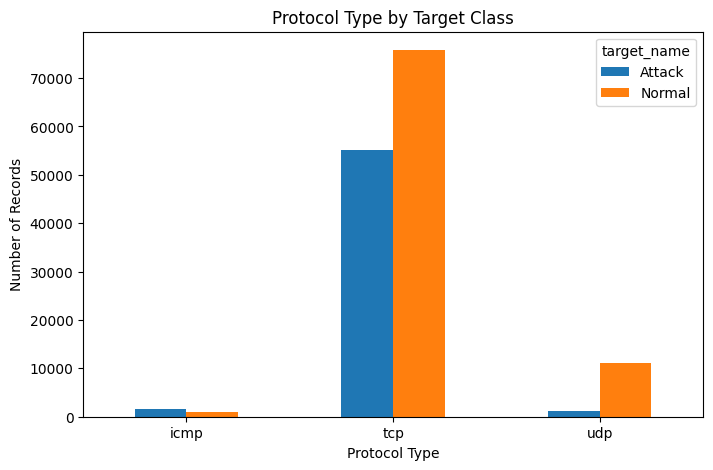

In [33]:
protocol_target_table.plot(kind="bar", figsize=(8, 5))
plt.title("Protocol Type by Target Class")
plt.xlabel("Protocol Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

In [34]:
top_services = df_clean["service"].value_counts().head(15)

top_services

service
http        62054
private     49057
smtp         9721
domain_u     5425
other        4769
ftp_data     4592
ecr_i        1027
eco_i         916
ftp           798
finger        668
telnet        512
urp_i         443
auth          328
ntp_u         290
pop_3         200
Name: count, dtype: int64

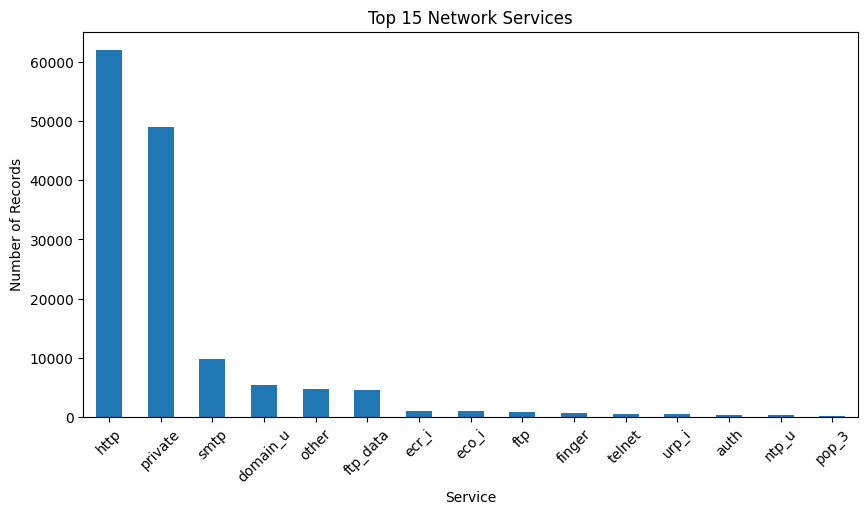

In [35]:
plt.figure(figsize=(10, 5))
top_services.plot(kind="bar")
plt.title("Top 15 Network Services")
plt.xlabel("Service")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

In [36]:
flag_counts = df_clean["flag"].value_counts()

flag_counts

flag
SF        87459
S0        42278
REJ       14712
RSTO        569
RSTR        425
S1           57
SH           34
S2           24
RSTOS0       11
S3           10
OTH           7
Name: count, dtype: int64

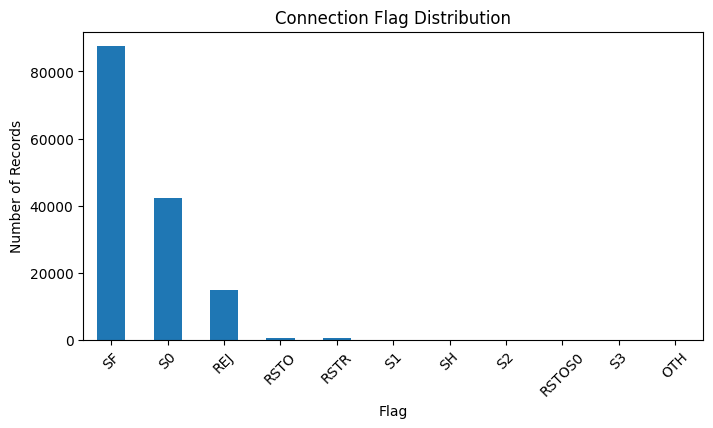

In [37]:
plt.figure(figsize=(8, 4))
flag_counts.plot(kind="bar")
plt.title("Connection Flag Distribution")
plt.xlabel("Flag")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

In [38]:
categorical_columns_clean = df_clean.select_dtypes(include=["object"]).columns.tolist()
numerical_columns_clean = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:")
print(categorical_columns_clean)

print("\nNumber of numerical columns:")
print(len(numerical_columns_clean))

print("\nNumerical columns:")
print(numerical_columns_clean)

Categorical columns:
['protocol_type', 'service', 'flag', 'label', 'target_name']

Number of numerical columns:
37

Numerical columns:
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'target']


/var/folders/s3/bj6s78k94q94mmyl5jf6tq_40000gn/T/ipykernel_31819/2697325709.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns_clean = df_clean.select_dtypes(include=["object"]).columns.tolist()


In [39]:
important_features = [
    "duration",
    "src_bytes",
    "dst_bytes",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "dst_host_count",
    "dst_host_srv_count"
]

available_important_features = [col for col in important_features if col in df_clean.columns]

df_clean.groupby("target_name")[available_important_features].mean().T

target_name,Attack,Normal
duration,45.480971,188.932394
src_bytes,18223.731620,1270.249226
dst_bytes,1550.618156,3720.620423
count,174.050923,8.850578
srv_count,14.691156,11.906982
serror_rate,0.731835,0.001757
srv_serror_rate,0.731919,0.001987
dst_host_count,245.076531,139.642454
dst_host_srv_count,17.988711,203.544836


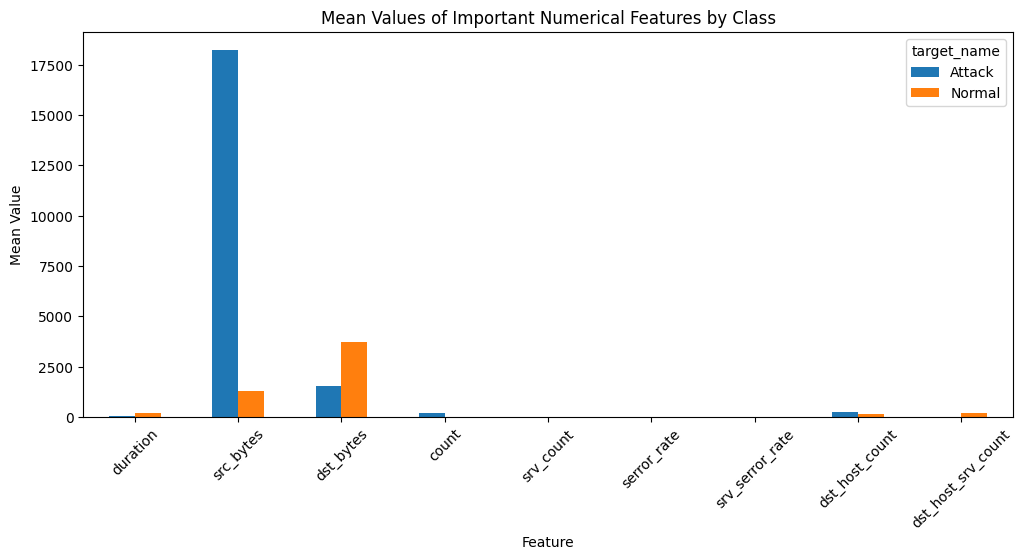

In [40]:
feature_means = df_clean.groupby("target_name")[available_important_features].mean().T

feature_means.plot(kind="bar", figsize=(12, 5))
plt.title("Mean Values of Important Numerical Features by Class")
plt.xlabel("Feature")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.show()

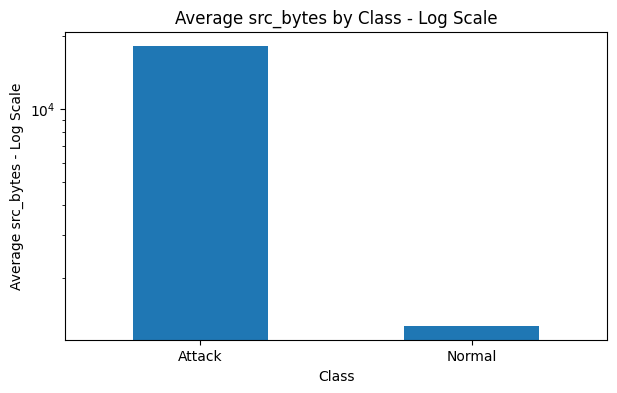

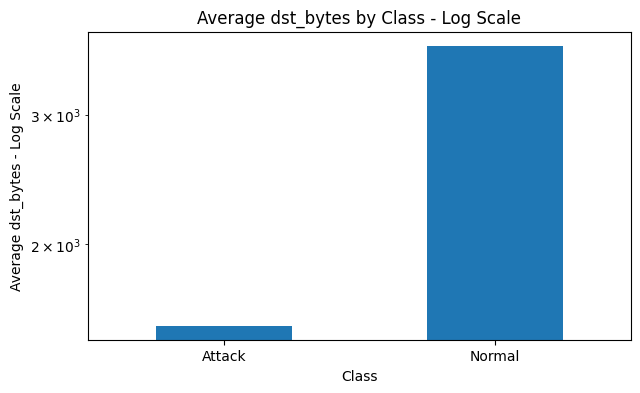

In [41]:
byte_features = ["src_bytes", "dst_bytes"]

for feature in byte_features:
    if feature in df_clean.columns:
        plt.figure(figsize=(7, 4))
        df_clean.groupby("target_name")[feature].mean().plot(kind="bar", logy=True)
        plt.title(f"Average {feature} by Class - Log Scale")
        plt.xlabel("Class")
        plt.ylabel(f"Average {feature} - Log Scale")
        plt.xticks(rotation=0)
        plt.show()

In [42]:
numeric_df = df_clean.select_dtypes(include=["int64", "float64"])

correlation_matrix = numeric_df.corr()

correlation_matrix.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,target
duration,1.000000,0.004280,0.002582,-0.001264,-0.009102,0.003707,0.009855,0.004343,-0.090667,0.061454,0.021395,0.058895,0.059745,0.078000,-0.001435,0.023886,0.020268,-0.078036,-0.040818,-0.069311,-0.069252,0.004626,0.004850,0.059618,0.051852,-0.039164,0.062703,-0.116824,-0.120372,0.429391,0.353500,-0.028847,-0.067714,-0.067908,-0.003710,0.002456,-0.057328
src_bytes,0.004280,1.000000,-0.000162,-0.000051,-0.000365,-0.000018,0.003999,-0.000077,-0.000928,0.000025,-0.000075,-0.000033,-0.000038,-0.000043,-0.000045,-0.000191,-0.000270,-0.001727,-0.001438,0.001787,0.001096,0.000315,0.001367,-0.002217,0.007307,-0.001144,-0.000117,-0.003937,-0.002144,0.000138,0.005619,0.000760,-0.001742,0.001111,-0.001092,0.001327,0.004556
dst_bytes,0.002582,-0.000162,1.000000,-0.000551,-0.003969,0.016147,0.000658,0.048789,0.028106,0.022755,0.031076,0.075442,0.020425,0.004285,-0.000454,0.007099,-0.000959,-0.032532,-0.009519,-0.029805,-0.029837,-0.016049,-0.015749,0.036113,-0.014592,-0.003977,-0.034975,0.013327,0.031658,-0.016820,0.028689,0.001728,-0.028956,-0.028726,-0.014865,-0.015282,-0.017458
land,-0.001264,-0.000051,-0.000551,1.000000,-0.000989,-0.000056,-0.000823,-0.000211,-0.011524,-0.000093,-0.000228,-0.000101,-0.000122,-0.000243,-0.000214,-0.000596,-0.000806,-0.008112,-0.004276,0.017473,0.018309,-0.002840,-0.004115,0.006868,0.001307,0.034247,-0.021110,-0.012802,0.007972,-0.002662,0.037464,0.106807,0.015462,0.008634,-0.003981,-0.004149,0.013257
wrong_fragment,-0.009102,-0.000365,-0.003969,-0.000989,1.000000,-0.000400,-0.005925,-0.001521,-0.082969,-0.000667,-0.001641,-0.000727,-0.000877,-0.001746,-0.001542,-0.004294,-0.005803,-0.013634,0.095968,-0.041159,-0.054248,-0.029163,-0.029628,0.051500,-0.021783,-0.025112,0.039512,-0.051512,-0.051003,0.085303,0.064637,-0.009676,-0.049449,-0.054156,0.029722,-0.029870,0.104075


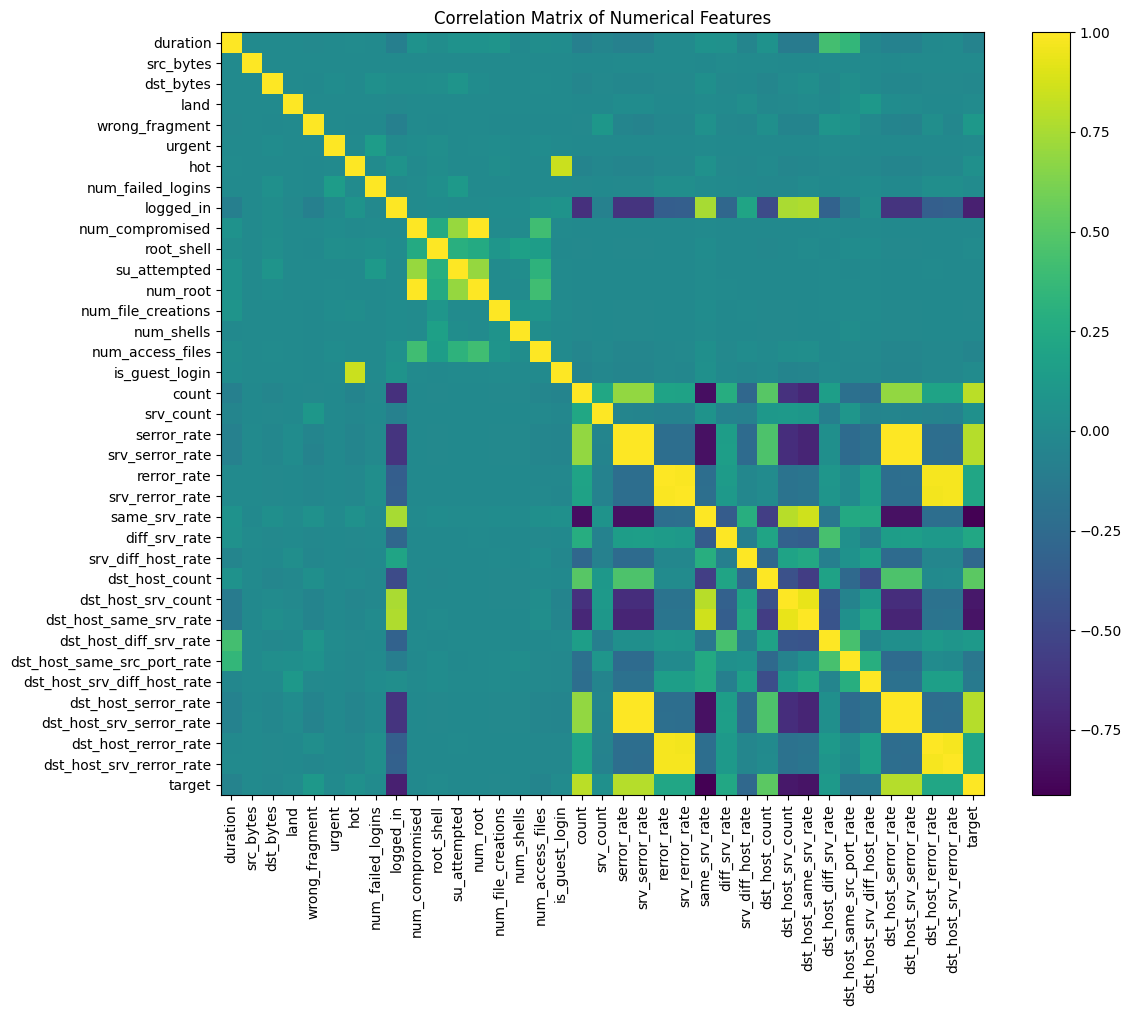

In [43]:
plt.figure(figsize=(12, 10))
plt.imshow(correlation_matrix)
plt.colorbar()
plt.title("Correlation Matrix of Numerical Features")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.tight_layout()
plt.show()

In [44]:
target_correlations = correlation_matrix["target"].drop("target").sort_values(key=abs, ascending=False)

target_correlations.head(15)

same_srv_rate              -0.912880
dst_host_same_srv_rate     -0.810683
count                       0.805478
dst_host_srv_count         -0.791325
serror_rate                 0.788613
dst_host_serror_rate        0.788309
dst_host_srv_serror_rate    0.788136
srv_serror_rate             0.787301
logged_in                  -0.742836
dst_host_count              0.520493
srv_diff_host_rate         -0.270178
diff_srv_rate               0.232374
dst_host_rerror_rate        0.218788
dst_host_srv_rerror_rate    0.216936
rerror_rate                 0.216392
Name: target, dtype: float64

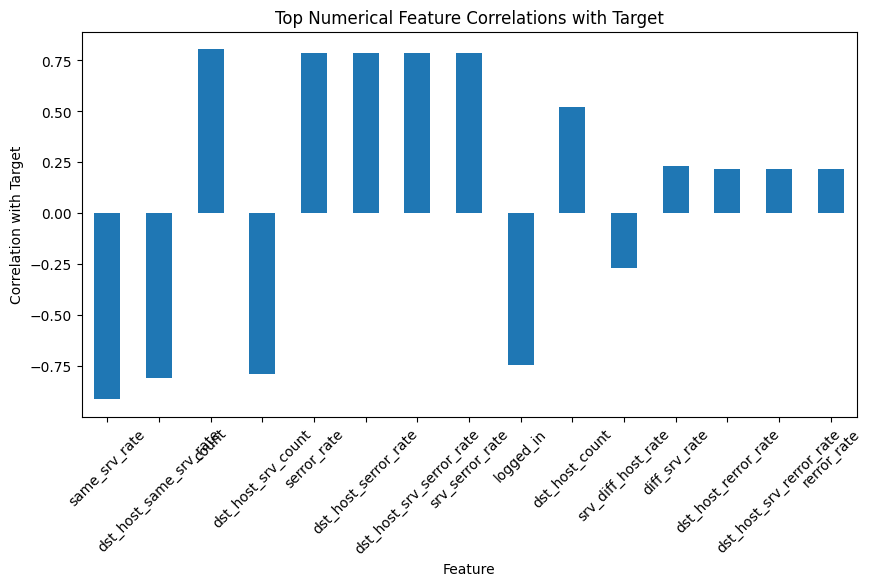

In [45]:
top_target_correlations = target_correlations.head(15)

plt.figure(figsize=(10, 5))
top_target_correlations.plot(kind="bar")
plt.title("Top Numerical Feature Correlations with Target")
plt.xlabel("Feature")
plt.ylabel("Correlation with Target")
plt.xticks(rotation=45)
plt.show()

## Outlier Analysis

Some numerical features such as `src_bytes`, `dst_bytes`, and `duration` contain very large values.

In a normal dataset, such values might be considered outliers. However, in a network intrusion detection problem, unusual values may actually represent suspicious or attack behavior.

Therefore, instead of removing these values blindly, we keep them in the dataset and handle scale differences later using preprocessing techniques such as StandardScaler.

This decision is important because removing extreme values may remove meaningful attack patterns.

In [46]:
cleaned_data_path = DATA_DIR / "cleaned_kdd_dataset.csv"

df_clean.to_csv(cleaned_data_path, index=False)

print("Cleaned dataset saved to:", cleaned_data_path)

Cleaned dataset saved to: /Users/arshia_mmz/Desktop/Uni/term 6/داده کاوی/Data-Mining/network-intrusion-detection-ml/data/cleaned_kdd_dataset.csv


## Feature Preparation for Modeling

In this section, we prepare the dataset for machine learning models.

The target variable is `target`, where:

- 0 means Normal connection
- 1 means Attack connection

The columns `label` and `target_name` are removed from the input features because they directly describe the target and should not be used as model inputs.

In [47]:
X = df_clean.drop(columns=["label", "target", "target_name"])
y = df_clean["target"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (145586, 39)
Target shape: (145586,)


In [48]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumber of categorical features:", len(categorical_features))

print("\nNumber of numerical features:", len(numerical_features))
print(numerical_features)

Categorical features:
['protocol_type', 'service', 'flag']

Number of categorical features: 3

Number of numerical features: 36
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


/var/folders/s3/bj6s78k94q94mmyl5jf6tq_40000gn/T/ipykernel_31819/1570381321.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\ny_test distribution:")
print(y_test.value_counts(normalize=True) * 100)

X_train shape: (116468, 39)
X_test shape: (29118, 39)
y_train distribution:
target
0    60.329876
1    39.670124
Name: proportion, dtype: float64

y_test distribution:
target
0    60.33038
1    39.66962
Name: proportion, dtype: float64


## Preprocessing Pipeline

The dataset contains both numerical and categorical features.

Preprocessing steps:

1. Numerical features are standardized using StandardScaler.
2. Categorical features are converted into numerical format using OneHotEncoder.
3. ColumnTransformer is used to apply the correct preprocessing method to each feature type.

In [50]:
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=True)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", one_hot_encoder, categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## Model Training

At least two different classification models are required.

In this project, we use four models:

1. Logistic Regression as a baseline model
2. Decision Tree as an interpretable model
3. Random Forest as a stronger ensemble model
4. K-Nearest Neighbors as a distance-based model

These models allow us to compare a simple linear model, tree-based models, an ensemble model, and a distance-based model.


In [51]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

models


{'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
 'Decision Tree': DecisionTreeClassifier(random_state=42),
 'Random Forest': RandomForestClassifier(n_jobs=-1, random_state=42)}

In [52]:
from sklearn.base import clone

def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    """
    Train and evaluate a classification model.
    Returns a dictionary of evaluation metrics.
    """
    
    pipeline = Pipeline(
        steps=[
            ("preprocessor", clone(preprocessor)),
            ("model", model)
        ]
    )
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1-score:", round(f1, 4))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["Normal", "Attack"], zero_division=0))
    
    return {
        "model_name": model_name,
        "pipeline": pipeline,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "y_pred": y_pred
    }

In [53]:
model_results = []

for model_name, model in models.items():
    result = evaluate_model(
        model_name=model_name,
        model=model,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test
    )
    
    model_results.append(result)

Logistic Regression
Accuracy: 0.9933
Precision: 0.9936
Recall: 0.9895
F1-score: 0.9915

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99     17567
      Attack       0.99      0.99      0.99     11551

    accuracy                           0.99     29118
   macro avg       0.99      0.99      0.99     29118
weighted avg       0.99      0.99      0.99     29118

Decision Tree
Accuracy: 0.9992
Precision: 0.9989
Recall: 0.9992
F1-score: 0.999

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     17567
      Attack       1.00      1.00      1.00     11551

    accuracy                           1.00     29118
   macro avg       1.00      1.00      1.00     29118
weighted avg       1.00      1.00      1.00     29118

Random Forest
Accuracy: 0.9994
Precision: 0.9997
Recall: 0.9989
F1-score: 0.9993

Classification Report:
              precision   

## K-Nearest Neighbors Model

K-Nearest Neighbors is a distance-based classification model.

Since KNN depends on distances between samples, feature scaling is very important. The existing preprocessing pipeline already applies `StandardScaler` to numerical features.

After One-Hot Encoding, the feature space becomes larger and sparse. Therefore, `TruncatedSVD` is used before KNN to reduce dimensionality and make the model more efficient.

Because KNN is computationally expensive on large datasets, it is trained on a stratified subset of the training data while still being evaluated on the full test set.


In [54]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.base import clone
import time


In [87]:
start_time = time.time()

knn_components = 30

knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("svd", TruncatedSVD(n_components=knn_components, random_state=42)),
        ("model", KNeighborsClassifier(
            n_neighbors=5,
            weights="distance",
            metric="minkowski",
            n_jobs=-1
        ))
    ]
)

knn_pipeline.fit(X_train, y_train)

knn_y_pred = knn_pipeline.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_y_pred)
knn_precision = precision_score(y_test, knn_y_pred, zero_division=0)
knn_recall = recall_score(y_test, knn_y_pred, zero_division=0)
knn_f1 = f1_score(y_test, knn_y_pred, zero_division=0)

end_time = time.time()

print("=" * 60)
print("K-Nearest Neighbors + TruncatedSVD")
print("=" * 60)
print("Training size:", len(X_train))
print("Test size:", len(X_test))
print("SVD components:", knn_components)
print("Accuracy:", round(knn_accuracy, 4))
print("Precision:", round(knn_precision, 4))
print("Recall:", round(knn_recall, 4))
print("F1-score:", round(knn_f1, 4))
print("Training and prediction time:", round(end_time - start_time, 2), "seconds")

print("\nClassification Report:")
print(classification_report(y_test, knn_y_pred, target_names=["Normal", "Attack"], zero_division=0))

K-Nearest Neighbors + TruncatedSVD
Training size: 116468
Test size: 29118
SVD components: 30
Accuracy: 0.9984
Precision: 0.9978
Recall: 0.998
F1-score: 0.9979
Training and prediction time: 1.61 seconds

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     17567
      Attack       1.00      1.00      1.00     11551

    accuracy                           1.00     29118
   macro avg       1.00      1.00      1.00     29118
weighted avg       1.00      1.00      1.00     29118



In [88]:
knn_result = {
    "model_name": "KNN + TruncatedSVD",
    "pipeline": knn_pipeline,
    "accuracy": knn_accuracy,
    "precision": knn_precision,
    "recall": knn_recall,
    "f1_score": knn_f1,
    "y_pred": knn_y_pred
}

model_results.append(knn_result)

print("KNN result added to model_results.")


KNN result added to model_results.


In [89]:
comparison_df = pd.DataFrame([
    {
        "Model": result["model_name"],
        "Accuracy": result["accuracy"],
        "Precision": result["precision"],
        "Recall": result["recall"],
        "F1-score": result["f1_score"]
    }
    for result in model_results
])

comparison_df = comparison_df.sort_values(by="F1-score", ascending=False).reset_index(drop=True)

comparison_df

,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.999416,0.999653,0.998875,0.999264
1,Decision Tree,0.999244,0.998875,0.999221,0.999048
2,KNN + TruncatedSVD,0.998352,0.997836,0.998009,0.997922
3,KNN + TruncatedSVD,0.997562,0.997659,0.996191,0.996924
4,Logistic Regression,0.993303,0.993567,0.989525,0.991542


In [90]:
print("Columns in X:")
print(X.columns.tolist())

leakage_keywords = ["label", "target", "attack", "class"]

possible_leakage_columns = [
    col for col in X.columns
    if any(keyword in col.lower() for keyword in leakage_keywords)
]

print("Possible leakage columns:")
print(possible_leakage_columns)

Columns in X:
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']
Possible leakage columns:
[]


In [91]:
train_distribution = y_train.value_counts(normalize=True).sort_index() * 100
test_distribution = y_test.value_counts(normalize=True).sort_index() * 100

balance_check = pd.DataFrame({
    "Train %": train_distribution.round(2),
    "Test %": test_distribution.round(2)
})

balance_check.index = ["Normal", "Attack"]

balance_check

,Train %,Test %
Normal,60.33,60.33
Attack,39.67,39.67


In [92]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(strategy="most_frequent", random_state=42)

dummy_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", dummy_model)
    ]
)

dummy_pipeline.fit(X_train, y_train)
dummy_pred = dummy_pipeline.predict(X_test)

print("Dummy Baseline Results")
print("Accuracy:", accuracy_score(y_test, dummy_pred))
print("Precision:", precision_score(y_test, dummy_pred, zero_division=0))
print("Recall:", recall_score(y_test, dummy_pred, zero_division=0))
print("F1-score:", f1_score(y_test, dummy_pred, zero_division=0))
print("\nClassification Report:")
print(classification_report(y_test, dummy_pred, target_names=["Normal", "Attack"], zero_division=0))

Dummy Baseline Results
Accuracy: 0.6033037983377979
Precision: 0.0
Recall: 0.0
F1-score: 0.0

Classification Report:
              precision    recall  f1-score   support

      Normal       0.60      1.00      0.75     17567
      Attack       0.00      0.00      0.00     11551

    accuracy                           0.60     29118
   macro avg       0.30      0.50      0.38     29118
weighted avg       0.36      0.60      0.45     29118



In [93]:
from sklearn.base import clone

sample_size = min(30000, len(X_train))

X_train_sample = X_train.sample(n=sample_size, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

y_train_shuffled = y_train_sample.sample(frac=1, random_state=42).reset_index(drop=True)
X_train_sample_reset = X_train_sample.reset_index(drop=True)

sanity_model = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", RandomForestClassifier(
            n_estimators=50,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

sanity_model.fit(X_train_sample_reset, y_train_shuffled)

X_test_sample = X_test.sample(n=min(10000, len(X_test)), random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

sanity_pred = sanity_model.predict(X_test_sample)

print("Shuffled Target Sanity Check")
print("Accuracy:", accuracy_score(y_test_sample, sanity_pred))
print("Precision:", precision_score(y_test_sample, sanity_pred, zero_division=0))
print("Recall:", recall_score(y_test_sample, sanity_pred, zero_division=0))
print("F1-score:", f1_score(y_test_sample, sanity_pred, zero_division=0))

Shuffled Target Sanity Check
Accuracy: 0.5942
Precision: 0.4826645890144137
Recall: 0.31216931216931215
F1-score: 0.3791309669522644


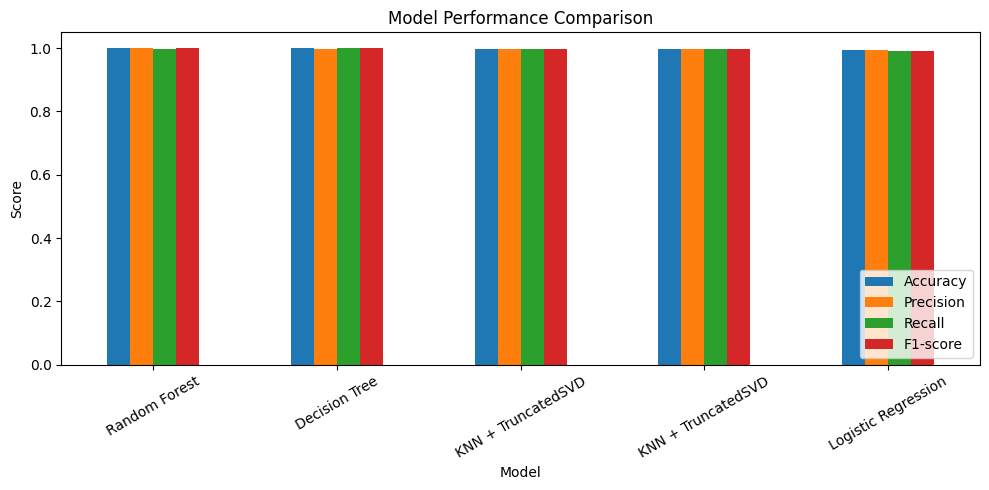

In [94]:
comparison_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=30)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Modeling Summary

In this section, four classification models were trained and evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors

The models were compared using Accuracy, Precision, Recall, F1-score, Confusion Matrix, and ROC Curve.

Since the dataset is related to intrusion detection, F1-score and Recall are more informative than Accuracy alone.

The best model is selected based on F1-score because it balances Precision and Recall.


## Detailed Model Evaluation

In this section, the trained models are evaluated more visually using:

1. Confusion Matrix
2. ROC Curve
3. AUC Score

The confusion matrix helps us understand the number of correct and incorrect predictions for Normal and Attack classes.

The ROC curve is useful because this is a binary classification problem.

In [95]:
FIGURES_DIR = OUTPUTS_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

print("Figures will be saved to:", FIGURES_DIR)

Figures will be saved to: /Users/arshia_mmz/Desktop/Uni/term 6/داده کاوی/Data-Mining/network-intrusion-detection-ml/outputs/figures


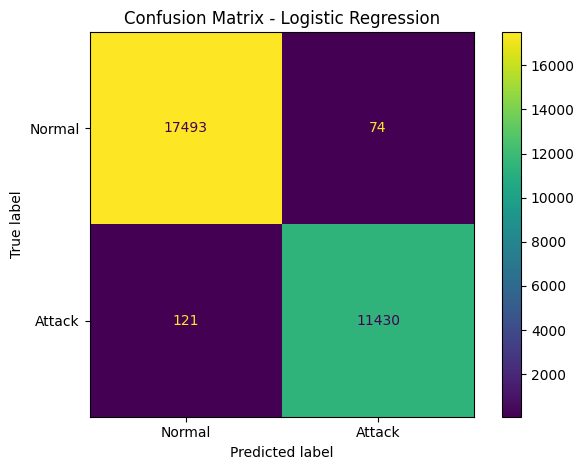

Saved: /Users/arshia_mmz/Desktop/Uni/term 6/داده کاوی/Data-Mining/network-intrusion-detection-ml/outputs/figures/confusion_matrix_logistic_regression.png


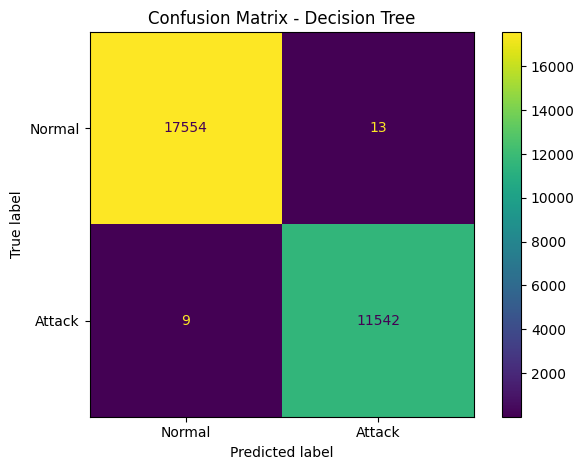

Saved: /Users/arshia_mmz/Desktop/Uni/term 6/داده کاوی/Data-Mining/network-intrusion-detection-ml/outputs/figures/confusion_matrix_decision_tree.png


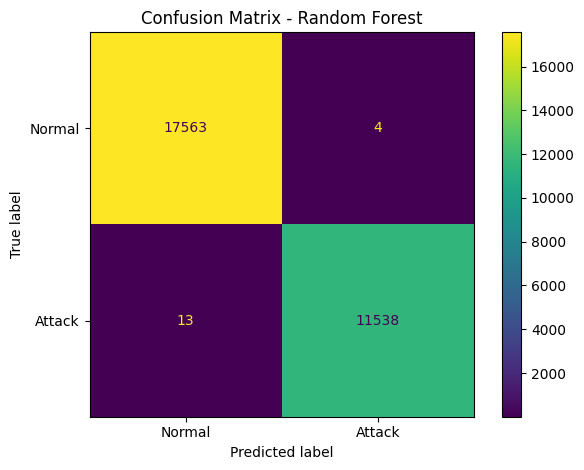

Saved: /Users/arshia_mmz/Desktop/Uni/term 6/داده کاوی/Data-Mining/network-intrusion-detection-ml/outputs/figures/confusion_matrix_random_forest.png


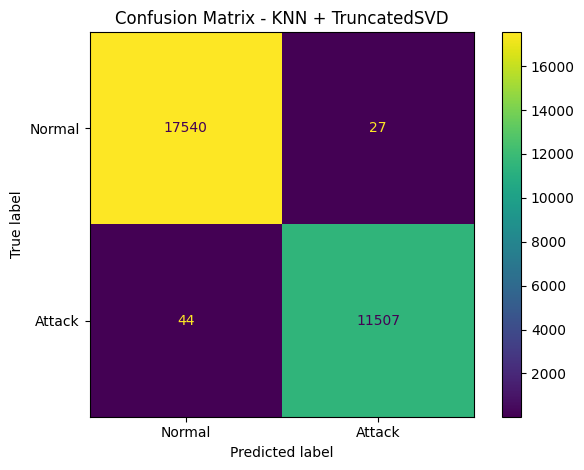

Saved: /Users/arshia_mmz/Desktop/Uni/term 6/داده کاوی/Data-Mining/network-intrusion-detection-ml/outputs/figures/confusion_matrix_knn_+_truncatedsvd.png


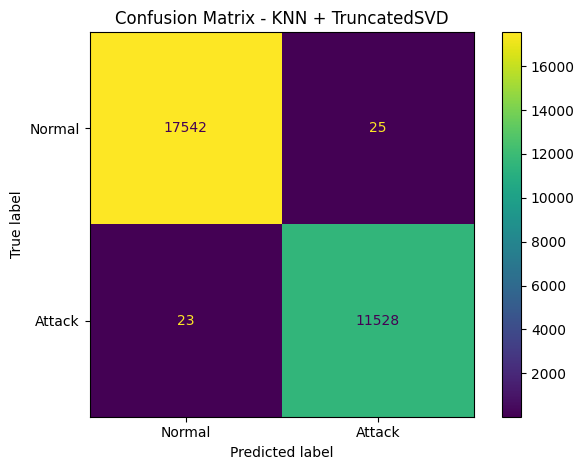

Saved: /Users/arshia_mmz/Desktop/Uni/term 6/داده کاوی/Data-Mining/network-intrusion-detection-ml/outputs/figures/confusion_matrix_knn_+_truncatedsvd.png


In [96]:
for result in model_results:
    model_name = result["model_name"]
    y_pred = result["y_pred"]
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Normal", "Attack"]
    )
    
    disp.plot()
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    
    figure_path = FIGURES_DIR / f"confusion_matrix_{model_name.lower().replace(' ', '_')}.png"
    plt.savefig(figure_path, dpi=300, bbox_inches="tight")
    
    plt.show()
    
    print(f"Saved: {figure_path}")

## Confusion Matrix Interpretation

The confusion matrix shows how many records were correctly or incorrectly classified.

For this intrusion detection problem:

- True Normal: normal connections correctly classified as normal
- False Alarm: normal connections incorrectly classified as attack
- Detected Attack: attack connections correctly classified as attack
- Missed Attack: attack connections incorrectly classified as normal

Missed attacks are especially important because they represent real attacks that were classified as normal.

Therefore, Recall and F1-score are important metrics for this project.

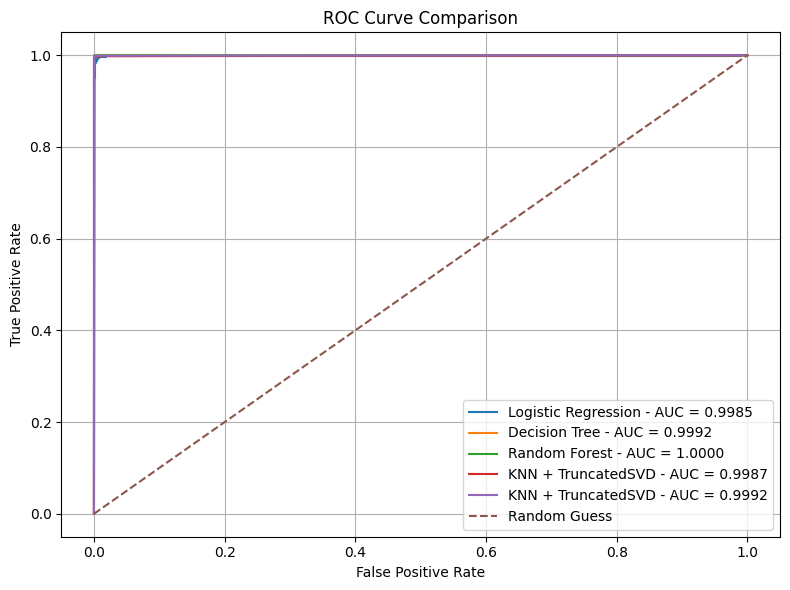

Saved: /Users/arshia_mmz/Desktop/Uni/term 6/داده کاوی/Data-Mining/network-intrusion-detection-ml/outputs/figures/roc_curve_comparison.png


In [97]:
plt.figure(figsize=(8, 6))

roc_results = []

for result in model_results:
    model_name = result["model_name"]
    pipeline = result["pipeline"]
    
    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        
        fpr, tpr, thresholds = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, label=f"{model_name} - AUC = {roc_auc:.4f}")
        
        roc_results.append({
            "Model": model_name,
            "AUC": roc_auc
        })

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()

roc_figure_path = FIGURES_DIR / "roc_curve_comparison.png"
plt.savefig(roc_figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved:", roc_figure_path)

In [98]:
roc_results_df = pd.DataFrame(roc_results).sort_values(by="AUC", ascending=False).reset_index(drop=True)

roc_results_df

,Model,AUC
0,Random Forest,0.999954
1,Decision Tree,0.999240
2,KNN + TruncatedSVD,0.999233
3,KNN + TruncatedSVD,0.998689
4,Logistic Regression,0.998531


In [99]:
roc_results_path = OUTPUTS_DIR / "roc_auc_results.csv"

roc_results_df.to_csv(roc_results_path, index=False)

print("ROC AUC results saved to:", roc_results_path)

ROC AUC results saved to: /Users/arshia_mmz/Desktop/Uni/term 6/داده کاوی/Data-Mining/network-intrusion-detection-ml/outputs/roc_auc_results.csv


## ROC Curve Interpretation

The ROC curve compares the trade-off between True Positive Rate and False Positive Rate.

A higher AUC value means the model is better at separating Normal and Attack connections.

Since this is a binary classification problem, ROC and AUC provide additional insight beyond Accuracy, Precision, Recall, and F1-score.

## Dimensionality Reduction

After preprocessing, categorical features are transformed using One-Hot Encoding. This increases the number of input features.

To analyze whether dimensionality reduction can help, we apply TruncatedSVD.

TruncatedSVD is suitable here because One-Hot Encoding creates a sparse feature matrix. It works similarly to PCA for sparse data and helps reduce the feature space while preserving important information.

We compare model performance before and after dimensionality reduction.

In [68]:
from sklearn.decomposition import TruncatedSVD
from sklearn.base import clone

In [100]:
svd_components = 30

svd_lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("svd", TruncatedSVD(n_components=svd_components, random_state=42)),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

svd_lr_pipeline.fit(X_train, y_train)

y_pred_svd_lr = svd_lr_pipeline.predict(X_test)

svd_lr_accuracy = accuracy_score(y_test, y_pred_svd_lr)
svd_lr_precision = precision_score(y_test, y_pred_svd_lr, zero_division=0)
svd_lr_recall = recall_score(y_test, y_pred_svd_lr, zero_division=0)
svd_lr_f1 = f1_score(y_test, y_pred_svd_lr, zero_division=0)

print("Logistic Regression with Dimensionality Reduction")
print("Accuracy:", round(svd_lr_accuracy, 4))
print("Precision:", round(svd_lr_precision, 4))
print("Recall:", round(svd_lr_recall, 4))
print("F1-score:", round(svd_lr_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svd_lr, target_names=["Normal", "Attack"], zero_division=0))

/Users/arshia_mmz/Desktop/Uni/term 6/داده کاوی/Data-Mining/network-intrusion-detection-ml/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression with Dimensionality Reduction
Accuracy: 0.9902
Precision: 0.9927
Recall: 0.9826
F1-score: 0.9876

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99     17567
      Attack       0.99      0.98      0.99     11551

    accuracy                           0.99     29118
   macro avg       0.99      0.99      0.99     29118
weighted avg       0.99      0.99      0.99     29118



In [101]:
explained_variance = svd_lr_pipeline.named_steps["svd"].explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance)

print("Total explained variance with", svd_components, "components:")
print(round(cumulative_explained_variance[-1], 4))

Total explained variance with 30 components:
0.9918


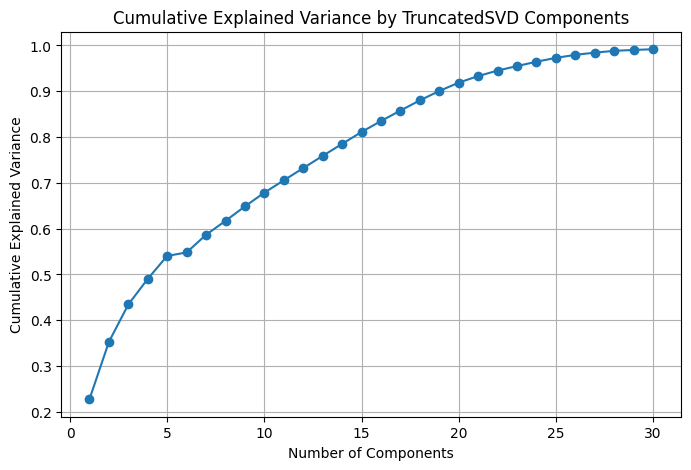

In [71]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, svd_components + 1), cumulative_explained_variance, marker="o")
plt.title("Cumulative Explained Variance by TruncatedSVD Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [102]:
original_lr_result = next(
    result for result in model_results
    if result["model_name"] == "Logistic Regression"
)

dimensionality_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Dimensionality Reduction": "No",
        "Accuracy": original_lr_result["accuracy"],
        "Precision": original_lr_result["precision"],
        "Recall": original_lr_result["recall"],
        "F1-score": original_lr_result["f1_score"]
    },
    {
        "Model": "Logistic Regression + TruncatedSVD",
        "Dimensionality Reduction": "Yes",
        "Accuracy": svd_lr_accuracy,
        "Precision": svd_lr_precision,
        "Recall": svd_lr_recall,
        "F1-score": svd_lr_f1
    }
])

dimensionality_comparison

,Model,Dimensionality Reduction,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,No,0.993303,0.993567,0.989525,0.991542
1,Logistic Regression + TruncatedSVD,Yes,0.990212,0.992653,0.982599,0.987601


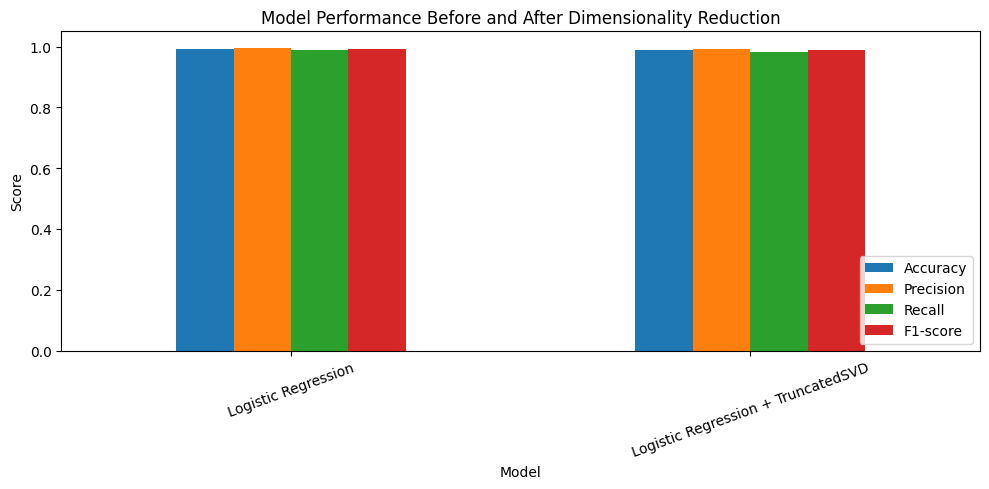

In [103]:
dimensionality_comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Model Performance Before and After Dimensionality Reduction")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

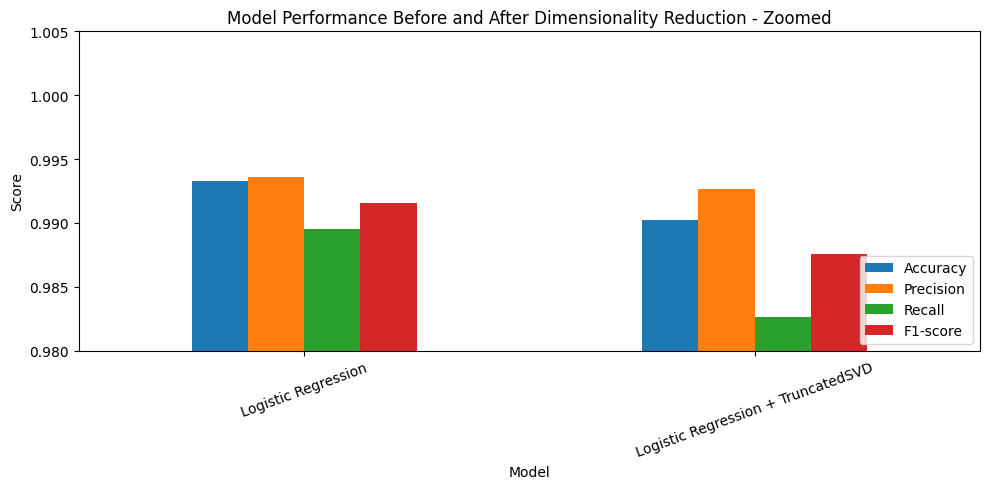

In [104]:
dimensionality_comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Model Performance Before and After Dimensionality Reduction - Zoomed")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.98, 1.005)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Dimensionality Reduction Interpretation

The dimensionality reduction step was used to reduce the feature space after One-Hot Encoding.

The performance before and after dimensionality reduction was compared using the same model.

If the performance decreases, it means that some useful information may have been lost during dimensionality reduction.

If the performance remains close to the original model, it means dimensionality reduction can simplify the feature space while preserving most of the useful information.

## Clustering Analysis

Before relying only on supervised classification models, we also analyze the internal structure of the data without using labels.

For this purpose, we use:

1. TruncatedSVD to reduce the data to 2 dimensions for visualization
2. KMeans clustering to group the records
3. Comparison between clusters and the real target labels

The goal is not to build the best classifier, but to see whether the data naturally forms meaningful groups.

In [105]:
# Use the full cleaned dataset for clustering
X_cluster_sample = X.copy()
y_cluster_sample = y.copy()

print("Clustering data shape:", X_cluster_sample.shape)
print("Target distribution in clustering data:")
print(y_cluster_sample.value_counts(normalize=True) * 100)

Clustering data shape: (145586, 39)
Target distribution in clustering data:
target
0    60.329977
1    39.670023
Name: proportion, dtype: float64


In [106]:
preprocessor_for_clustering = clone(preprocessor)

X_cluster_preprocessed = preprocessor_for_clustering.fit_transform(X_cluster_sample)

print("Preprocessed clustering data shape:", X_cluster_preprocessed.shape)

Preprocessed clustering data shape: (145586, 116)


In [107]:
svd_2d = TruncatedSVD(n_components=2, random_state=42)

X_cluster_2d = svd_2d.fit_transform(X_cluster_preprocessed)

print("2D data shape:", X_cluster_2d.shape)
print("Explained variance by 2 components:", round(svd_2d.explained_variance_ratio_.sum(), 4))

2D data shape: (145586, 2)
Explained variance by 2 components: 0.3525


In [108]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_cluster_2d)

cluster_results = pd.DataFrame({
    "component_1": X_cluster_2d[:, 0],
    "component_2": X_cluster_2d[:, 1],
    "cluster": cluster_labels,
    "actual_target": y_cluster_sample.values
})

cluster_results.head()

,component_1,component_2,cluster,actual_target
0,2.193737,-0.701506,1,0
1,2.179719,-0.725307,1,0
2,2.178098,-0.739525,1,0
3,2.186974,-0.748011,1,0
4,2.188096,-0.759655,1,0


In [109]:
# Compare clusters with actual labels
cluster_label_comparison = pd.crosstab(
    cluster_results["cluster"],
    cluster_results["actual_target"],
    rownames=["Cluster"],
    colnames=["Actual Target"]
)

display(cluster_label_comparison)

# Map each cluster to the majority actual target inside that cluster
cluster_to_target_mapping = cluster_label_comparison.idxmax(axis=1).to_dict()

print("Cluster to target mapping:")
print(cluster_to_target_mapping)

# Create a new column where cluster labels are aligned with actual target labels
cluster_results["cluster_mapped_to_target"] = cluster_results["cluster"].map(cluster_to_target_mapping)

cluster_results.head()

Actual Target,0,1
Cluster,,
0,1099,53186
1,86733,4568


Cluster to target mapping:
{0: 1, 1: 0}


,component_1,component_2,cluster,actual_target,cluster_mapped_to_target
0,2.193737,-0.701506,1,0,0
1,2.179719,-0.725307,1,0,0
2,2.178098,-0.739525,1,0,0
3,2.186974,-0.748011,1,0,0
4,2.188096,-0.759655,1,0,0


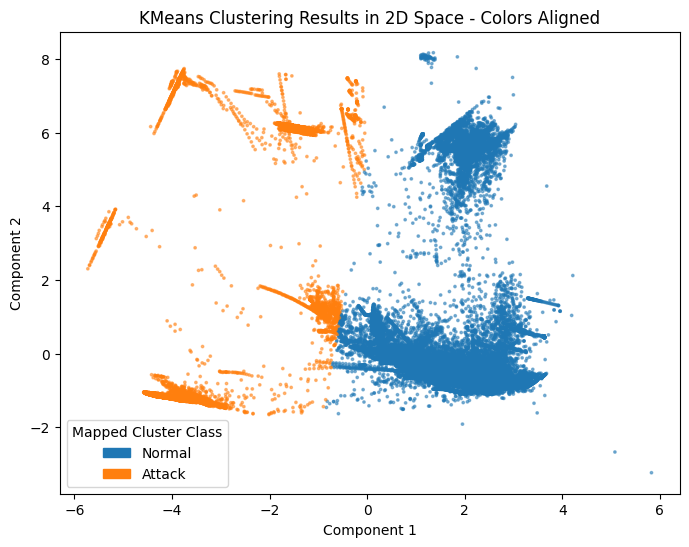

In [110]:
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# Consistent colors:
# 0 = Normal
# 1 = Attack
class_cmap = ListedColormap(["tab:blue", "tab:orange"])

plt.figure(figsize=(8, 6))

plt.scatter(
    cluster_results["component_1"],
    cluster_results["component_2"],
    c=cluster_results["cluster_mapped_to_target"],
    cmap=class_cmap,
    vmin=0,
    vmax=1,
    s=3,
    alpha=0.5
)

plt.title("KMeans Clustering Results in 2D Space - Colors Aligned")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

legend_elements = [
    mpatches.Patch(color="tab:blue", label="Normal"),
    mpatches.Patch(color="tab:orange", label="Attack")
]

plt.legend(handles=legend_elements, title="Mapped Cluster Class")
plt.show()

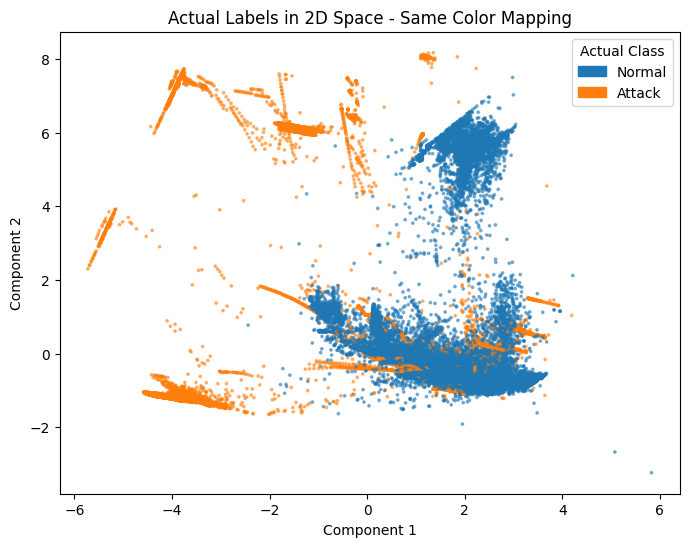

In [111]:
plt.figure(figsize=(8, 6))

plt.scatter(
    cluster_results["component_1"],
    cluster_results["component_2"],
    c=cluster_results["actual_target"],
    cmap=class_cmap,
    vmin=0,
    vmax=1,
    s=3,
    alpha=0.5
)

plt.title("Actual Labels in 2D Space - Same Color Mapping")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

legend_elements = [
    mpatches.Patch(color="tab:blue", label="Normal"),
    mpatches.Patch(color="tab:orange", label="Attack")
]

plt.legend(handles=legend_elements, title="Actual Class")
plt.show()

In [112]:
cluster_label_comparison

Actual Target,0,1
Cluster,,
0,1099,53186
1,86733,4568


In [113]:
from sklearn.metrics import adjusted_rand_score

ari_score = adjusted_rand_score(
    cluster_results["actual_target"],
    cluster_results["cluster"]
)

print("Adjusted Rand Index:", round(ari_score, 4))

Adjusted Rand Index: 0.8499


## Clustering Interpretation

KMeans clustering was applied without using the target labels.

The resulting clusters were compared with the actual Normal/Attack labels.

If the clusters match the real labels well, it means the data has a strong natural separation between normal and attack connections.

If the match is weak, it means supervised learning is necessary because the class structure is not fully captured by simple clustering.

In [114]:
cluster_results_path = OUTPUTS_DIR / "clustering_results.csv"

cluster_results.to_csv(cluster_results_path, index=False)

print("Clustering results saved to:", cluster_results_path)

Clustering results saved to: /Users/arshia_mmz/Desktop/Uni/term 6/داده کاوی/Data-Mining/network-intrusion-detection-ml/outputs/clustering_results.csv


In [115]:
print("Final Model Comparison:")
display(comparison_df)

print("\nDimensionality Reduction Comparison:")
display(dimensionality_comparison)

print("\nClustering vs Actual Labels:")
display(cluster_label_comparison)

print("\nAdjusted Rand Index:")
print(round(ari_score, 4))

if "cluster_purity" in globals():
    print("\nCluster Purity:")
    print(round(cluster_purity, 4))

Final Model Comparison:


,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.999416,0.999653,0.998875,0.999264
1,Decision Tree,0.999244,0.998875,0.999221,0.999048
2,KNN + TruncatedSVD,0.998352,0.997836,0.998009,0.997922
3,KNN + TruncatedSVD,0.997562,0.997659,0.996191,0.996924
4,Logistic Regression,0.993303,0.993567,0.989525,0.991542



Dimensionality Reduction Comparison:


,Model,Dimensionality Reduction,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,No,0.993303,0.993567,0.989525,0.991542
1,Logistic Regression + TruncatedSVD,Yes,0.990212,0.992653,0.982599,0.987601



Clustering vs Actual Labels:


Actual Target,0,1
Cluster,,
0,1099,53186
1,86733,4568



Adjusted Rand Index:
0.8499


In [116]:
# Make sure best model variables exist
best_result = max(model_results, key=lambda x: x["f1_score"])

best_model_name = best_result["model_name"]

final_summary = {
    "best_model": best_model_name,
    "best_accuracy": best_result["accuracy"],
    "best_precision": best_result["precision"],
    "best_recall": best_result["recall"],
    "best_f1_score": best_result["f1_score"],
    "ari_score": ari_score
}

if "cluster_purity" in globals():
    final_summary["cluster_purity"] = cluster_purity

final_summary_df = pd.DataFrame([final_summary])

final_summary_path = OUTPUTS_DIR / "final_project_summary.csv"
final_summary_df.to_csv(final_summary_path, index=False)

final_summary_df

,best_model,best_accuracy,best_precision,best_recall,best_f1_score,ari_score
0,Random Forest,0.999416,0.999653,0.998875,0.999264,0.849944


## Final Conclusion

In this project, a machine learning-based decision support system was designed for network intrusion detection.

The dataset used was the KDD Cup 1999 intrusion detection dataset. Each record represents a network connection, and the main objective was to classify each connection as either Normal or Attack.

The project followed a complete data mining pipeline:

1. Data understanding
2. Data quality checking
3. Data cleaning
4. Exploratory data analysis
5. Feature preprocessing
6. Model training
7. Model evaluation
8. Dimensionality reduction
9. Clustering analysis

The original labels were converted into a binary target:

- Normal connections were labeled as 0
- Attack connections were labeled as 1

Duplicate records were removed because the dataset contained many repeated rows, which could make the model evaluation unrealistic.

Four classification models were trained and compared:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors

The models were evaluated using Accuracy, Precision, Recall, F1-score, Confusion Matrix, and ROC Curve.

The best model was selected based on F1-score. In the main results, Random Forest achieved the best overall performance based on F1-score. This model performed better because it can capture complex and non-linear relationships between network traffic features.

To make sure the high performance was not caused by data leakage, two sanity checks were performed:

1. Dummy Baseline Model
2. Shuffled Target Sanity Check

The Dummy model performed poorly compared to the trained models, and the shuffled target test caused a significant performance drop. These results confirm that the trained models learned meaningful patterns from the data.

Dimensionality reduction using TruncatedSVD was also tested. The results showed that dimensionality reduction did not significantly improve performance, but it was useful for simplifying the feature space and supporting clustering visualization.

Finally, KMeans clustering was applied without using the target labels. The clusters showed strong agreement with the actual Normal/Attack labels, which means the dataset has a meaningful internal structure. However, supervised classification models were still more accurate and reliable for intrusion detection.